In [1]:
import warnings
from pathlib import Path

import numpy as np
import prism

from imagematerials import vehicles as vhc
from imagematerials.concepts import create_vehicle_graph
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance
from imagematerials.model import (
    GenericMaterials,
    GenericStocks,
)
from imagematerials.util import (
    export_to_netcdf,
    import_from_netcdf,
    read_circular_economy_config,
    read_climate_policy_config,
    rebroadcast_prep_data,
)


In [2]:
base_dir = "../data/raw"
climate_policy_scenario_dir = Path(base_dir) / 'SSP2'
circular_economy_scenario_dirs = {"base": Path(base_dir) / 'circular_economy_scenarios' / 'base'}
prep_fp = Path("prep_vema.nc")
# note: configuration currently only works when no prep file is saved

In [3]:
def get_vema_prep():
    base_dir = Path("..", "data", "raw")
    prep_fp = Path("prep_vema.nc")
    if not prep_fp.is_file():
        climate_policy_scenario_dir = base_dir / 'SSP2'
        circular_economy_scenario_dirs = {"slow": base_dir / 'circular_economy_scenarios' / 'slow'}

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            climate_policy_config = read_climate_policy_config(climate_policy_scenario_dir)
            circular_economy_config = read_circular_economy_config(circular_economy_scenario_dirs)
            prep_data = vhc.preprocess(base_dir, climate_policy_config, circular_economy_config)

        export_to_netcdf(prep_data, prep_fp)

    prep_data = import_from_netcdf(prep_fp)
    output_coords_type = list(prep_data["stocks"].Type.values)
    knowledge_graph = prep_data["knowledge_graph"]
    new_prep_data = rebroadcast_prep_data(prep_data, knowledge_graph, dim="Type", output_coords=output_coords_type)
    region_coords = np.sort(prep_data["stocks"].coords["Region"].values.astype(int)).astype(str)[:-2]
    new_prep_data = rebroadcast_prep_data(new_prep_data, knowledge_graph, dim="Region", output_coords=region_coords)

    new_prep_data["weights"] = new_prep_data.pop("vehicle_weights")
    sec_vhc = Sector("vhc", new_prep_data)
    return sec_vhc
vhc_sector = get_vema_prep()

In [4]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1807
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [5]:
# Currently not functional

# Define the coordinates of all dimensions.
# Region = list(prep_data["stocks"].coords["Region"].values)
# Time = [t for t in complete_timeline]
# Cohort = Time
# Type = list(prep_data["stocks"].coords["Type"].values)
# material = list(prep_data["material_fractions"].coords["material"].values)

#main_model_normal = GenericMainModel(
#    complete_timeline, Region=Region, Time=Time, Cohort=Cohort, Type=Type, prep_data=prep_data,
#    compute_materials=True, compute_battery_materials=False, compute_maintenance_materials=False,
#    material=material, knowledge_graph=knowledge_graph)

In [6]:
# main_model_normal.simulate(simulation_timeline)

In [7]:
main_model_factory = ModelFactory(
    vhc_sector, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

In [8]:
warnings.filterwarnings("ignore")
main_model_factory.simulate(simulation_timeline)

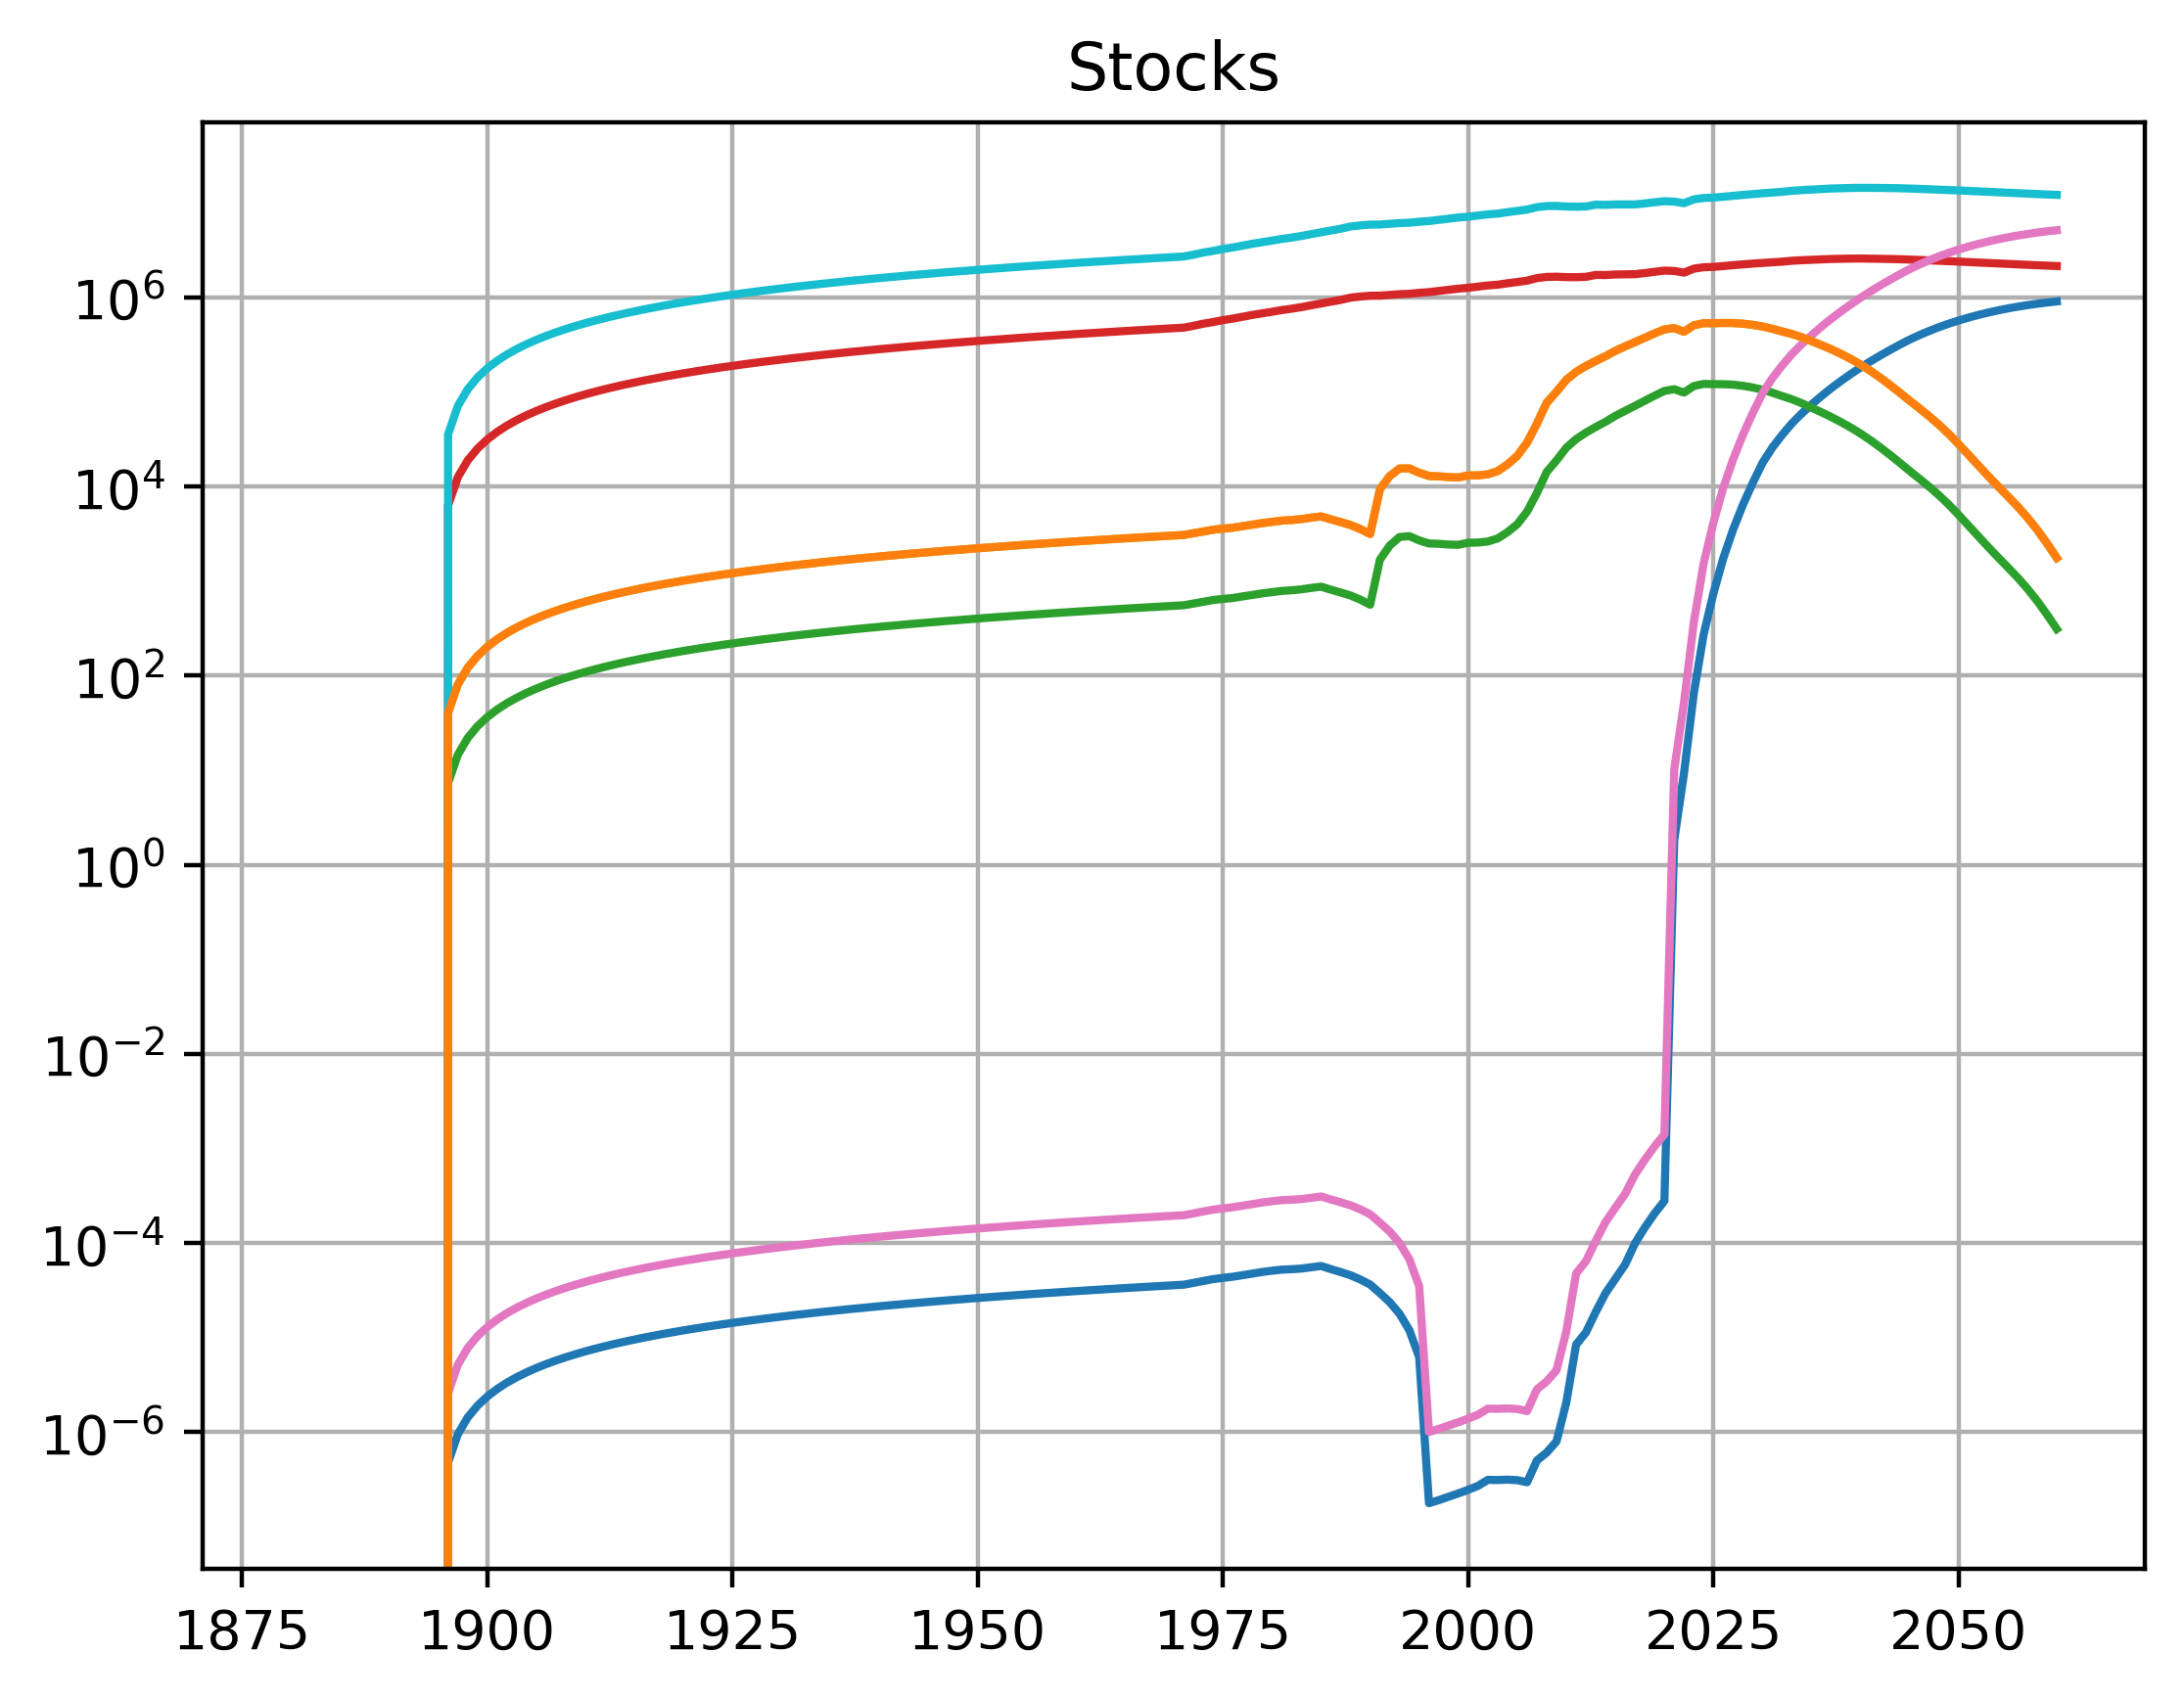

In [9]:
from matplotlib import pyplot as plt

plt.figure(dpi=400)
plt.yscale("log")
plt.title("Stocks")
plt.grid()
sub_array = main_model_factory.vhc["stocks"].loc[1880:]
for t in main_model_factory.vhc["stocks"].coords["Type"].values:
    if "Buses" in t:

        plt.plot(sub_array.Time, sub_array.sum("Region").sel(Type=t).sel(), label=t)
plt.show()